In [30]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import ts_onset_cess as ocd
import pandas as pd
from fapar_def import fapar_read

import warnings
warnings.filterwarnings('ignore')

In [ ]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
Y1=1990
Y2=2024
comps = 3

### Read in calculated recycling to add to the precipitation plots

In [32]:
#datao ="/Volumes/ESA_F4R/ed_prepare/2026_rho/mint_r02_it1000_tole3/bands_rho/" 
datao = "/Volumes/ESA_F4R/ed_prepare/2026_rho/nudge_mint_r02_it1000_tole3/"
S_NAME = "S_SE" # S_SE or S_LSE 
L_NAME = "L_M" # L_M or L_HI
band = {'N':[5,12,10,31],'EQ':[-5,5,8,29],'S':[-15,-5,12,31]}
rho_xarr={}
for B in ['N','EQ','S']:
    print('running band:', B)
    #rho_xarr[B] = xr.open_mfdataset(datao+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc",engine='netcdf4')
    rho_xarr[B] = xr.open_mfdataset(datao+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc",engine='netcdf4')
    rho_xarr[B] = rho_xarr[B].sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))

running band: N
running band: EQ
running band: S


### Calculate roatational means for each month and band


In [33]:
#Monthly average plots - average rotation
rho_mon = {}
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for B in ['N','EQ','S']:
    rho_mon[B] = rho_xarr[B]['rho'].mean('rot') 
        

### Read in precip 
- do this for whole available ts and then sub-select years in next step for analysis

In [34]:
#Y1=1981
#Y2=2025
#for Y in range(Y1,Y2+1):
#    prp = xr.open_mfdataset('/Volumes/blue_wd/chirps_daily/chirps-v2.0.'+str(Y)+'.days_p05.nc')['precip']
#    prp = prp.rename({'latitude':'lat','longitude':'lon'})
#    prpN = prp.sel(lat=slice(5,12),lon=slice(10,31),drop=True).load()
#    prpEQ = prp.sel(lat=slice(-5,5),lon=slice(8,29),drop=True).load()
#    prpS = prp.sel(lat=slice(-15,-5),lon=slice(12,31),drop=True).load()
#    if Y==Y1:
#        prpaN = prpN
#        prpaEQ = prpEQ
#        prpaS = prpS
#    else:
#        prpaN = xr.concat([prpaN,prpN],dim='time')
#        prpaEQ = xr.concat([prpaEQ,prpEQ],dim='time')
#        prpaS = xr.concat([prpaS,prpS],dim='time')
#        prpN.close()
#        prpEQ.close()
#        prpS.close()
#prpaN.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_N.nc',engine='h5netcdf')
#prpaN.close()
#prpaEQ.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_EQ.nc',engine='h5netcdf')
#prpaEQ.close()
#prpaS.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_S.nc',engine='h5netcdf')
#prpaS.close()
#        

In [35]:
pr = {}
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_N.nc')['precip']
pr['N'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_EQ.nc')['precip']
pr['EQ'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_S.nc')['precip']
pr['S'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))


## Equatorial Band

- Checking to see if wet and dry seasons have consistently different onset and cessation dates

- Calculate wet and dry season composites for season 1 and season 2

- Calculate the onset and cessation of full climatology for all seasons

- Calculate onset and cessation of wet and dry composite seasons

- Calculate mean of onset and cessation composites

- Plot everything

In [36]:
#Equatorial Band

P = pr['EQ'] 
R = rho_mon['EQ']
RM = R.groupby('time.month').mean(dim=('time','lat','lon'))
RM = RM.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))

#Composite season years - S1
PA = P.mean(dim=('lat','lon')).where((P['time.dayofyear']<162)&(P['time.dayofyear']>42)).groupby('time.year').mean('time')
sort_index = PA.sortby(PA)
dryS1 = sort_index[0:comps]['year']
wetS1 = sort_index[-comps:]['year']
print('Dry years S1',dryS1['year'].values)
print('Wet years S1',wetS1['year'].values)
PW1 = P.sel(time=P['time.year'].isin(wetS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD1 = P.sel(time=P['time.year'].isin(dryS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
RW1 = R.sel(time=R['time.year'].isin(wetS1['year'].values)).groupby('time.month').mean(dim=('time','lat','lon'))
RD1 = R.sel(time=R['time.year'].isin(dryS1['year'].values)).groupby('time.month').mean(dim=('time','lat','lon'))
RW1 = RW1.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))
RD1 = RD1.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))
#Composite season years - S2
PA = P.mean(dim=('lat','lon')).where((P['time.dayofyear']<361)&(P['time.dayofyear']>227)).groupby('time.year').mean('time')
sort_index = PA.sortby(PA)
dryS2 = sort_index[0:comps]['year']
wetS2 = sort_index[-comps:]['year']
print('Dry years S2',dryS2['year'].values)
print('Wet years S2',wetS2['year'].values)
PW2 = P.sel(time=P['time.year'].isin(wetS2['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD2 = P.sel(time=P['time.year'].isin(dryS2['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
RW2 = R.sel(time=R['time.year'].isin(wetS2['year'].values)).groupby('time.month').mean(dim=('time','lat','lon'))
RD2 = R.sel(time=R['time.year'].isin(dryS2['year'].values)).groupby('time.month').mean(dim=('time','lat','lon'))
RW2 = RW2.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))
RD2 = RD2.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))
print('----------------------------------------------------')



Dry years S1 [2004 2010 2011]
Wet years S1 [2008 2007 2014]
Dry years S2 [2015 2009 2014]
Wet years S2 [2013 2007 2012]
----------------------------------------------------


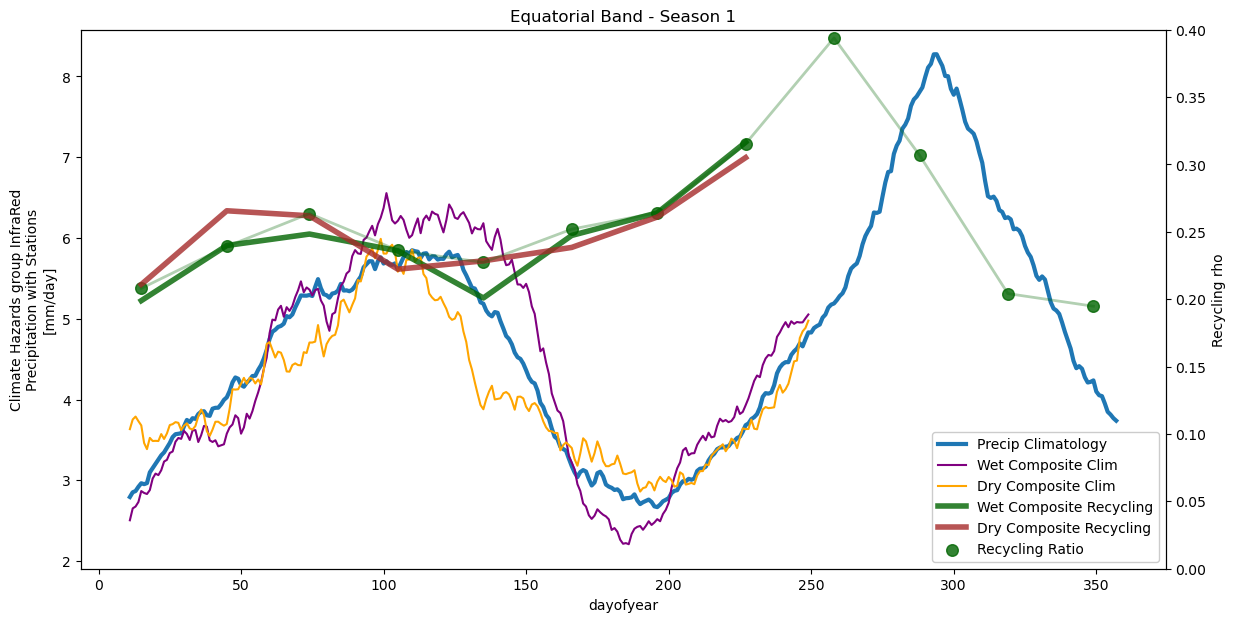

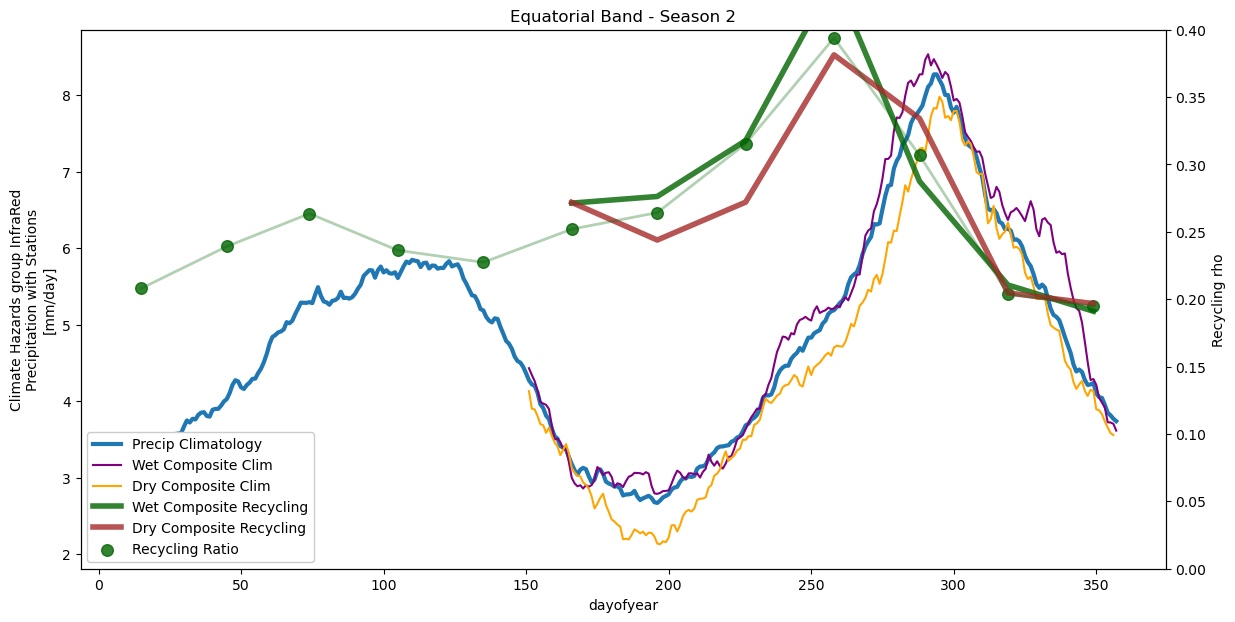

In [37]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

PW1R = PW1.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW1['dayofyear']<250)
PD1R = PD1.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW1['dayofyear']<250)
PW1R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD1R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()

ax2.plot(RW1['dayofyear'].where(RW1['dayofyear']<250),RW1.where(RW1['dayofyear']<250),linestyle='-',linewidth=4,color='darkgreen',alpha=0.8,label='Wet Composite Recycling')
ax2.plot(RD1['dayofyear'].where(RD1['dayofyear']<250),RD1.where(RD1['dayofyear']<250),linestyle='-',linewidth=4,color='brown',alpha=0.8,label="Dry Composite Recycling")
ax2.set(ylim=(0,0.4), ylabel='Recycling')

ax2.plot(RM['dayofyear'],RM,linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(RM['dayofyear'],RM,s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling rho')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2, labels + labels2, framealpha=1.0, loc='lower right')

plt.title('Equatorial Band - Season 1')
plt.savefig(datap+'EQ_S1_comp_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()
plt.close()


#Plot everything - SEASON 2

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

PW2R = PW2.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW2['dayofyear']>150)
PD2R = PD2.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW2['dayofyear']>150)
PW2R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD2R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()

ax2.plot(RW2['dayofyear'].where(RW2['dayofyear']>150),RW2.where(RW2['dayofyear']>150),linestyle='-',linewidth=4,color='darkgreen',alpha=0.8,label='Wet Composite Recycling')
ax2.plot(RD2['dayofyear'].where(RD2['dayofyear']>150),RD2.where(RD2['dayofyear']>150),linestyle='-',linewidth=4,color='brown',alpha=0.8,label="Dry Composite Recycling")
ax2.set(ylim=(0,0.4), ylabel='Recycling')

ax2.plot(RM['dayofyear'],RM,linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(RM['dayofyear'],RM,s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling rho')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2, labels + labels2, framealpha=1.0, loc='lower left')

plt.title('Equatorial Band - Season 2')
plt.savefig(datap+'EQ_S2_comp_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()
plt.close()


In [38]:
#Northern Band

P = pr['N'] 
R = rho_mon['N']
RM = R.groupby('time.month').mean(dim=('time','lat','lon'))
RM = RM.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))

#Composite season years - S1
PA = P.mean(dim=('lat','lon')).where((P['time.dayofyear']<277)&(P['time.dayofyear']>105)).groupby('time.year').mean('time')

sort_index = PA.sortby(PA)
dryS1 = sort_index[0:comps]['year']
wetS1 = sort_index[-comps:]['year']
print('Dry years S1',dryS1['year'].values)
print('Wet years S1',wetS1['year'].values)
PW1 = P.sel(time=P['time.year'].isin(wetS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD1 = P.sel(time=P['time.year'].isin(dryS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
RW1 = R.sel(time=R['time.year'].isin(wetS1['year'].values)).groupby('time.month').mean(dim=('time','lat','lon'))
RD1 = R.sel(time=R['time.year'].isin(dryS1['year'].values)).groupby('time.month').mean(dim=('time','lat','lon'))
RW1 = RW1.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))
RD1 = RD1.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))



Dry years S1 [2009 2004 2014]
Wet years S1 [2010 2006 2012]


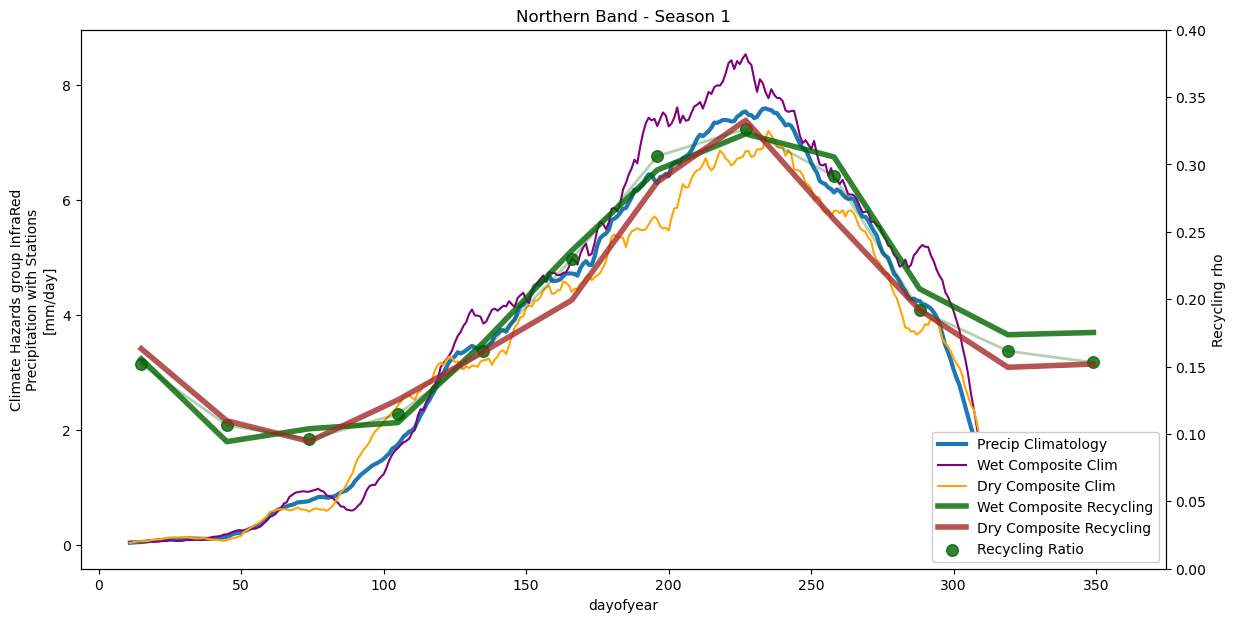

In [39]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

PW1R = PW1.rolling(dayofyear=20, center=True).mean('dayofyear')
PD1R = PD1.rolling(dayofyear=20, center=True).mean('dayofyear')
PW1R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD1R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()

ax2.plot(RW1['dayofyear'],RW1,linestyle='-',linewidth=4,color='darkgreen',alpha=0.8,label='Wet Composite Recycling')
ax2.plot(RD1['dayofyear'],RD1,linestyle='-',linewidth=4,color='brown',alpha=0.8,label="Dry Composite Recycling")
ax2.set(ylim=(0,0.4), ylabel='Recycling')

ax2.plot(RM['dayofyear'],RM,linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(RM['dayofyear'],RM,s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling rho')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2, labels + labels2, framealpha=1.0, loc='lower right')

plt.title('Northern Band - Season 1')
plt.savefig(datap+'N_S1_comp_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()
plt.close()



In [40]:
#Southern Band

P = pr['S'] 
R = rho_mon['S']
RM = R.groupby('time.month').mean(dim=('time','lat','lon'))
RM = RM.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))

PSY = P.groupby('time.year').mean(dim=('time','lat','lon'))
PSY = PSY[0:-1]
for i,y in enumerate(PSY['year'].values):
    pselect = P.sel(time=slice(str(y)+'-09-29',str(y+1)+'-05-08'),drop=True)
    pavg = pselect.mean(dim=('time','lat','lon'))
    PSY[str(y)]=pavg
#print(PSY)        

sort_index = PSY.sortby(PSY)
dryS1 = sort_index[0:comps]['year']
wetS1 = sort_index[-comps:]['year']
print('Dry years S1',dryS1['year'].values)
print('Wet years S1',wetS1['year'].values)

for i,y in enumerate(dryS1['year'].values):
    print(y)
    if i==0:
        PD1 = P.sel(time=slice(str(y)+'-07-01',str(y+1)+'-07-01')).mean(dim=('lat','lon'))
        RD1 = R.sel(time=slice(str(y)+'-07-01',str(y+1)+'-07-01')).mean(dim=('lat','lon'))
    else:
        PD1 = xr.concat([PD1,P.sel(time=slice(str(y)+'-07-01',str(y+1)+'-07-01'))],'time').mean(dim=('lat','lon'))
        RD1 = xr.concat([RD1,R.sel(time=slice(str(y)+'-07-01',str(y+1)+'-07-01'))],'time').mean(dim=('lat','lon'))
for i,y in enumerate(wetS1['year'].values):
    print(y)
    if i==0:
        PW1 = P.sel(time=slice(str(y)+'-07-01',str(y+1)+'-07-01')).mean(dim=('lat','lon'))
        RW1 = R.sel(time=slice(str(y)+'-07-01',str(y+1)+'-07-01')).mean(dim=('lat','lon'))
    else:
        PW1 = xr.concat([PW1,P.sel(time=slice(str(y)+'-07-01',str(y+1)+'-07-01'))],'time').mean(dim=('lat','lon'))
        RW1 = xr.concat([RW1,R.sel(time=slice(str(y)+'-07-01',str(y+1)+'-07-01'))],'time').mean(dim=('lat','lon'))
        

PW1 = PW1.groupby('time.dayofyear').mean(dim=('time'))
PD1 = PD1.groupby('time.dayofyear').mean(dim=('time'))
RW1 = RW1.groupby('time.month').mean(dim=('time'))
RD1 = RD1.groupby('time.month').mean(dim=('time'))
RW1 = RW1.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))
RD1 = RD1.assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))



Dry years S1 [2014 2005 2012]
Wet years S1 [2007 2006 2009]
2014
2005
2012
2007
2006
2009


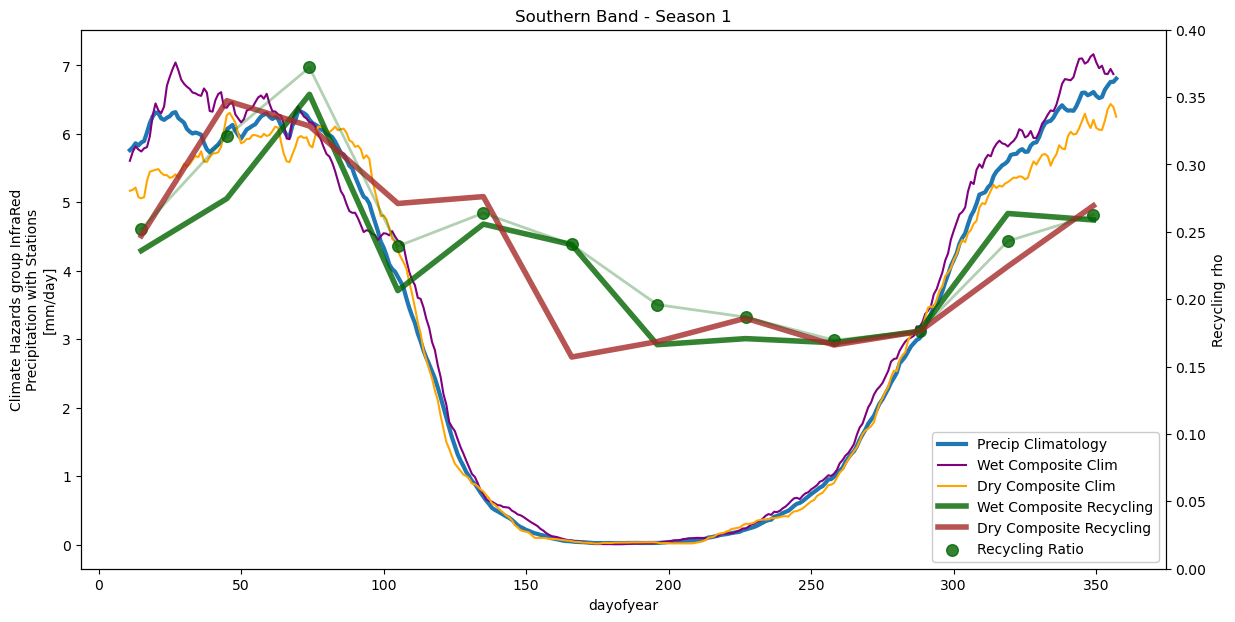

In [41]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

PW1R = PW1.rolling(dayofyear=20, center=True).mean('dayofyear')
PD1R = PD1.rolling(dayofyear=20, center=True).mean('dayofyear')
PW1R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD1R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()

ax2.plot(RW1['dayofyear'],RW1,linestyle='-',linewidth=4,color='darkgreen',alpha=0.8,label='Wet Composite Recycling')
ax2.plot(RD1['dayofyear'],RD1,linestyle='-',linewidth=4,color='brown',alpha=0.8,label="Dry Composite Recycling")
ax2.set(ylim=(0,0.4), ylabel='Recycling')

ax2.plot(RM['dayofyear'],RM,linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(RM['dayofyear'],RM,s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling rho')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2, labels + labels2, framealpha=1.0, loc='lower right')

plt.title('Southern Band - Season 1')
plt.savefig(datap+'S_S1_comp_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()
plt.close()

